In [1]:
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

In [2]:
def marchpast(l, g):
     "Marchenko-Pastur distribution"
     def m0(a):
         "Element wise maximum of (a,0)"
         return np.maximum(a, np.zeros_like(a))
     gplus=(1+g**0.5)**2
     gminus=(1-g**0.5)**2
     return np.sqrt(m0(gplus  - l)*m0(l- gminus)) / ( 2*np.pi*g*l)

FileNotFoundError: [Errno 2] No such file or directory: 'Th_60/populational_Th_60_results.npz'

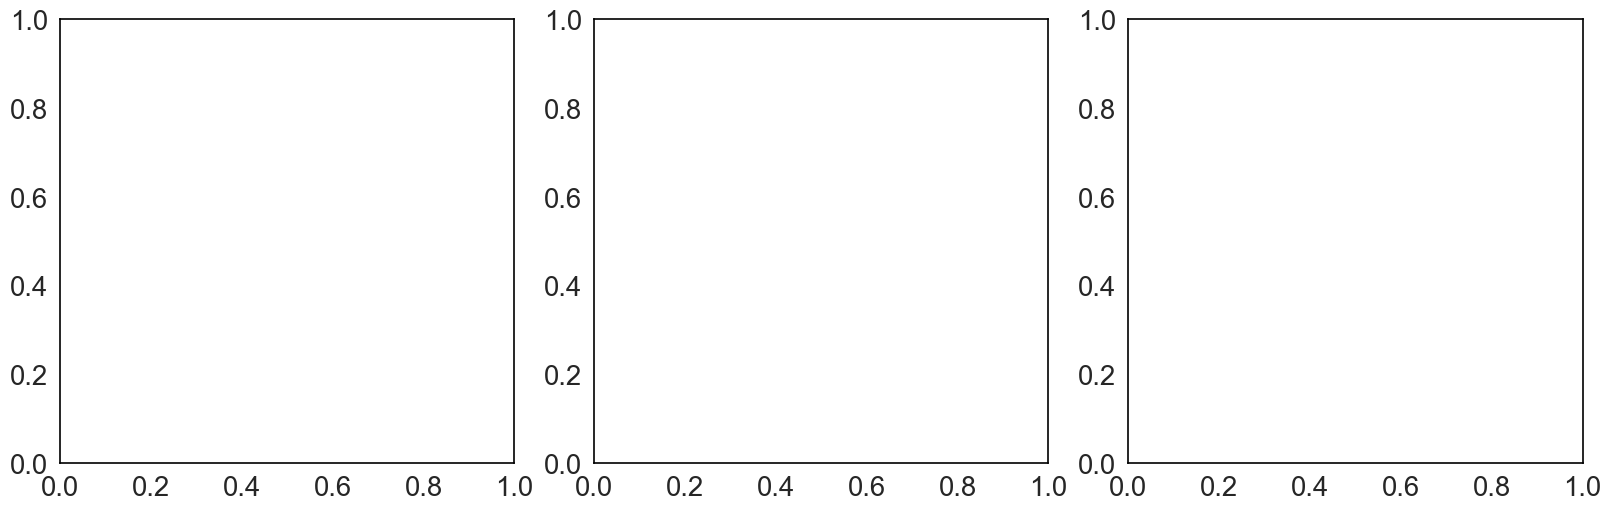

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Style Settings (Nat Comm aesthetic) ===
sns.set_context("talk", font_scale=1.2)
sns.set_style("whitegrid", {'axes.grid': False})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.linewidth': 1.2,
    'axes.edgecolor': 'black',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
})

# === Function for Marchenko–Pastur Distribution ===
def marchpast(x, gamma):
    lam_min = (1 - np.sqrt(1/gamma))**2 if gamma > 1 else (1 - np.sqrt(gamma))**2
    lam_max = (1 + np.sqrt(1/gamma))**2 if gamma > 1 else (1 + np.sqrt(gamma))**2
    density = np.zeros_like(x)
    valid = (x >= lam_min) & (x <= lam_max)
    density[valid] = np.sqrt((lam_max - x[valid]) * (x[valid] - lam_min)) / (2 * np.pi * gamma * x[valid])
    return density

# === Parameters ===
init_scale = 2165
Th_values = [60, 300, 600]
x_limits = (8e-4, 1e2)
y_limits = (1e-4, 4e1)
letters = ['a', 'b', 'c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for i, Th in enumerate(Th_values):
    # Load data
    data = np.load(f'Th_{Th}/populational_Th_{Th}_results.npz')
    fcm_dts = data['fcm_dts_reduced']
    eigenvalues_FC_dts = np.linalg.eigvalsh(fcm_dts)
    eigenvalues_FC_dts = eigenvalues_FC_dts[eigenvalues_FC_dts > 0]

    # Compute histogram
    binsc_dts = np.logspace(np.log10(0.01 * np.min(eigenvalues_FC_dts)),
                            np.log10(np.max(eigenvalues_FC_dts)), num=60)
    probc_dts, _ = np.histogram(eigenvalues_FC_dts, bins=binsc_dts, density=True)
    bin_centers_dts = (binsc_dts[:-1] + binsc_dts[1:]) / 2
    probc_dts[probc_dts < 1e-5] = np.nan

    # Marchenko–Pastur
    T = 640
    N = fcm_dts.shape[1]
    gamma = N / T
    x_dense = np.logspace(np.log10(min(binsc_dts)), np.log10(max(binsc_dts)), 400)
    mp_density = marchpast(x_dense, gamma)

    # === Plot ===
    ax = axes[i]
    ax.plot(bin_centers_dts, probc_dts, 'o-', color='#7ab8d6', lw=2.5, markersize=5, label='Empirical spectrum')
    ax.plot(x_dense, mp_density, '--', color='#d62728', lw=2.5, label='Marchenko–Pastur')
    ax.fill_between(x_dense, mp_density, alpha=0.1, color='#d62728')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.set_title(f'$N\' = {Th}$', fontsize=15)
    ax.text(0.02, 0.95, f'({letters[i]})', transform=ax.transAxes, fontsize=16, va='top', ha='left', fontweight='bold')

    if i != 4:
        ax.set_ylabel(r'$P(\lambda)$', fontsize=14)
    ax.set_xlabel(r'$\lambda$', fontsize=14)
    if i == 0:
        ax.legend(frameon=False, loc='lower left', fontsize=12)

sns.despine()
plt.savefig('Fig2_eigenvalue_spectra_NatComm_style.svg', bbox_inches='tight', dpi=600)
plt.show()
